In [1]:
!pip install -U pycaret

In [2]:
import sys
import pycaret

print(sys.version)
print(pycaret.__version__)

3.11.9 (tags/v3.11.9:de54cf5, Apr  2 2024, 10:12:12) [MSC v.1938 64 bit (AMD64)]
3.3.2


In [3]:
import numpy as np
import pandas as pd

In [4]:
df_features = pd.read_excel("C:/Users/Nilofar/Desktop/Remote Sensing/Loredana/input_INGV_GRINS_Landslide_EGMS.xlsx")   
df_target_construction_2024 = pd.read_excel("C:/Users/Nilofar/Desktop/Remote Sensing/Loredana/raw data/P2_2024_it_Comuni_percentage score.xlsx")          
df_target_construction_2001 = pd.read_excel("C:/Users/Nilofar/Desktop/Remote Sensing/Loredana/RBD-Dataset-2001processed.xlsx")                     

In [5]:
df_temp = pd.merge(df_features, df_target_construction_2024,
                      left_on='PROCOM', right_on='Codice comune', how='inner')
merged_df  = pd.merge(df_temp, df_target_construction_2001, on='PROCOM', how='inner')
print('Merged shape:', merged_df.shape)

Merged shape: (7858, 568)


In [6]:
#  Build target variable
def clean_numeric(series):
    if series.dtype == 'object':
        return pd.to_numeric(series.astype(str).str.replace(',', '.'), errors='coerce')
    return series

pop_2024_col = 'Popolazione censita al 31 dicembre - Totale'
pop_2001_col = 'POP_2001'

merged_df[pop_2024_col] = clean_numeric(merged_df[pop_2024_col])
merged_df[pop_2001_col] = clean_numeric(merged_df[pop_2001_col])

merged_df['target'] = (
    (merged_df[pop_2024_col] - merged_df[pop_2001_col]) * 100 / merged_df[pop_2001_col]
)
merged_df = merged_df.replace([np.inf, -np.inf], np.nan)
merged_df = merged_df.dropna(subset=['target'])
merged_df = merged_df.reset_index(drop=True)   # clean 0-based index
print(f'Final dataset size: {merged_df.shape}')

Final dataset size: (7856, 569)


In [7]:
exclude_cols = ['DATA_RIF','ID_TERRITORIO_IND','ID_REGIONE','DZREG','CODPRO','DZPRO',
                'PROCOM','DZCOM_x','LIT_TXT','ZONA_ALT_TXT','CLASSE_COMUNE_TXT',
                'MACRO_CLASSE_TXT','PRES_EUAP_TXT','DEGREE_URB_TXT','COMUNE_MONTANO_TXT',
                'ZNVULC_G_TXT','ZNVULC_R_TXT','ZNVULC_SOM_TXT','ZNVULC_ALTRI_TXT','DENSPOP',
                'ERECQ_TXT','Codice comune','DZCOM_y','y','lat','long','PRO_COM_110',
                'FAM_2011_P','FAM_2011_R','FAM_2018_P','FAM_2018_R','ETA_Q2','ETA_Q1','A3_XCENT',
                'POP_2011_P','POP_2011_R','FAM_2011','FAM_2018','Percentage_Score',
                'POP_2018_R','POP_2018_P','VAR_PERC','target','pop_2024_col,pop_2001_col',
                'TOT_BENI_R','A2_R','E19_R','A2_P','TOT_BENI_P','E3_R','E3_P',
                'E7_R','E12_R','E14_R','E10_R','E14_P','E16_R','E11_R','E20_R','ERE16_XCENT',
                'ETA_Q3','ECP3_13_15_R','EP3E6_R','ERE15','EMC_M_R',
                'A3_P','A3_R','A7_R','E08_E12_P','E08_E12_R','E10_P','VAR_PERC_R',
                'E10_R','E11_P','E11_R','E12_P','E12_R','E13_E15_P','E13_E15_R',
                'E14_P','E14_R','E15_P','E15_R','E16_R','E18_P','E18_R','E19_E20_P',
                'E19_E20_R','E19_R','E16_XCENT','EMC_M_P','A7_XCENT','E20_P','E20_R',
                'E28_P','E28_R','E29_P','E29_R','E31_P','E31_R','E5_P','E5_R','E6_P',
                'ECP3_13_15_P','EMC_P_P','E6_R','VAR_PERC_P','PAI_POPP3_P4_P','PAI_POPP3_P4_R',
                'PAI_POPP4_R','POP_2018_P','POP_2018_R','TOT_ARCHIT_P','EMC_O_P',
                'IND_DIP_STR_R','TOT_ARCHIT_R','ALT_MAX_P','IND_DIP_STR_P','ETA_Q1_P',
                'E16_XCENT_R','ERE16_R','ERE16_P','ALT_LOC_AB','ALT_MAX_R','ETA_Q4_P',
                'ETA_Q4_R','PAI_POPAA_R','PAI_POPP1_R','PAI_POPP2_R','PAI_POPP3_R',
                'TOT_ARCHEO_R','TOT_BENI_R','TOT_PARC_GIAR_R','EC13_15_R','E16_XCENT_P',
                'EC13_15_P','EP3M_R','E28_R','EMC_P_R','EMP1_R','EMC_O_R','ERE13_R',
                'ECP3_8_12_R','ERE13_P','VECCH','EC8_12_R','CLASSE_COMUNE','EP3C1_R','SUP',
                'EP3E6_P','EMP3_R','EMP1_P','ERECEM','SOC_01','POP_2018','POP_2011','IFC (decili)',
                'POP_ANZ_P','POP_ANZ_R','IND_DIP_STR','Intra_Disparity_CV_health','Percentage_Score_2024','lat_municipality','Pendolarism_Rate_2021','long_municipality',
                'TOT_PARC_GIAR_P','Moving_From','Intra_Disparity_CV_health', 'EME8_R','EME8_P','EME9_R','EME9_P','EME10_R','EME10_P','EME11_R','EME11_P','PAI_AREAP3_R','PAI_AREAP3_P','PAI_AREAP4_R',
                'PAI_AREAP4_P','PAI_AREAP5_R','PAI_AREAP5_P'
                'DZCOM','Municipality', 'IDEM', 'IVSM', 'IVSM_2024', 'IVSM_2001', 'IVSM_2024_2001', 'IVSM_2024_2001_percentage'
]

In [8]:
feature_cols = df_features.columns.difference(['PROCOM'])
X = merged_df[feature_cols].copy()
y = merged_df['target'].copy()

X = X.drop(columns=[c for c in exclude_cols if c in X.columns], errors='ignore')
X = X.apply(clean_numeric)

cat_cols = X.select_dtypes(include=['object']).columns.tolist()
cat_to_encode = [c for c in cat_cols if X[c].nunique() < 20]
print(f'One-Hot Encoding: {cat_to_encode}')
X = pd.get_dummies(X, columns=cat_to_encode, drop_first=True)
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

# Ensure X and y share the same clean index
X = X.reset_index(drop=True)
y = y.reset_index(drop=True)

print(f'Feature matrix: {X.shape},  target: {y.shape}')

One-Hot Encoding: []
Feature matrix: (7856, 353),  target: (7856,)


In [9]:
# Initialize PyCaret setup
from pycaret.regression import *

s = setup(data=X, target=y, session_id=123, verbose=False, preprocess=False)

Now, let's compare different regression models to identify the best performing one based on various metrics.

In [10]:
# Compare and select the best model based on R2
compare_models(sort='R2')

,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,5.9251,76.9219,8.6976,0.8123,0.6820,1.5288,2.4480
rf,Random Forest Regressor,6.2392,84.4834,9.1248,0.7936,0.7047,1.5396,71.8850
dt,Decision Tree Regressor,9.3613,174.2733,13.1730,0.5687,0.8833,2.4371,0.9150
dummy,Dummy Regressor,15.1344,405.8020,20.1019,-0.0014,1.8267,1.2286,0.0680


LGBMRegressor(n_jobs=-1, random_state=123)

In [12]:
# Compare models to find the best one
best_model = compare_models(n_select=1, verbose=False)

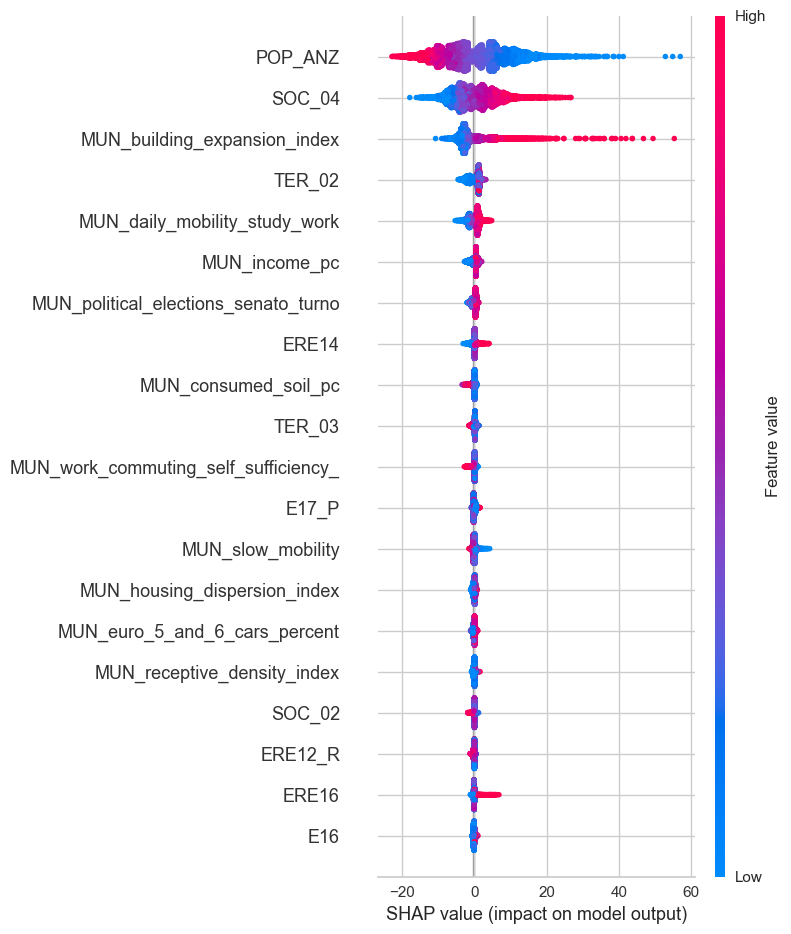

In [13]:
import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X)

shap.summary_plot(shap_values, X)

After comparing, I will tune the hyperparameters of the best model found.

In [ ]:
# Tune hyperparameters of the best model
tuned_best_model = tune_model(best_model, optimize='RMSE', verbose=False)

In [ ]:
best_model = create_model('lightgbm', verbose=False)
tuned_best_model = tune_model(best_model, optimize='R2', verbose=False)

In [ ]:
# Visualizza le prestazioni del modello tunato
tuned_model_results = pull()
display(tuned_model_results)

,MAE,MSE,RMSE,R2,RMSLE,MAPE
Fold,,,,,,
0,6.3789,92.9441,9.6408,0.8135,0.7017,1.3202
1,5.9562,61.1295,7.8185,0.8427,0.6905,1.4535
2,5.8125,71.1687,8.4362,0.8164,0.7094,1.7808
3,5.9718,64.8604,8.0536,0.8099,0.7170,1.8316
4,6.2673,77.4422,8.8001,0.7881,0.7395,1.5728
5,5.7279,61.8847,7.8667,0.8353,0.6799,1.0933
6,5.9239,67.7642,8.2319,0.8281,0.6838,1.0380
7,6.0521,69.6139,8.3435,0.8273,0.6952,1.1826
8,6.5403,159.9286,12.6463,0.6922,0.7476,2.7941


Finally, I will finalize the tuned model for deployment or further analysis.

In [ ]:
# Finalize the model
final_model = finalize_model(tuned_best_model)

print("Best Model after tuning and finalization:")
print(final_model)

Best Model after tuning and finalization:
Pipeline(memory=Memory(location=None),
         steps=[('placeholder', None),
                ('actual_estimator',
                 LGBMRegressor(n_jobs=-1, random_state=123))])


### Valutazione del `final_model`
Per una valutazione più approfondita del `final_model`, PyCaret offre la funzione `evaluate_model()` che mostra una serie di grafici interattivi e metriche.

In [ ]:
# Valuta il modello finale
#evaluate_model(final_model)

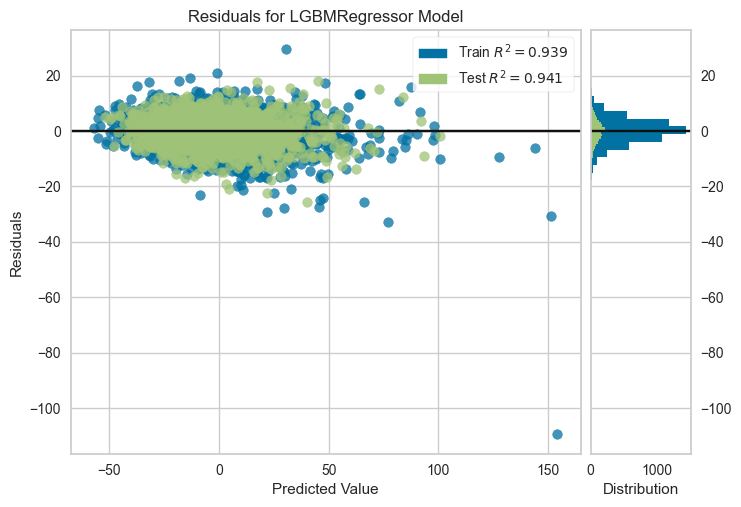

In [ ]:
import matplotlib.pyplot as plt

# Plot dei residui (Residuals Plot)
plot_model(final_model, plot='residuals', save=False)
plt.show()

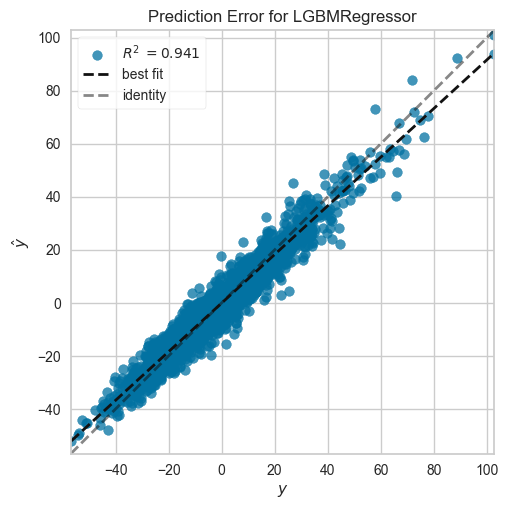

In [ ]:
# Plot di previsione (Prediction Error Plot)
plot_model(final_model, plot='error', save=False)
plt.show()

In [ ]:
# Installa la libreria SHAP se non è già installata
pip install shap

INFO: pip is looking at multiple versions of pandas to determine which version is compatible with other requirements. This could take a while.
INFO: pip is looking at multiple versions of scipy to determine which version is compatible with other requirements. This could take a while.
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
    --------------------------------------- 0.3/12.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/12.6 MB 4.8 MB/s eta 0:00:03
   -------------- ------------------------- 4.5/12.6 MB 9.9 MB/s eta 0:00:01
   ------------------ --------------------- 5.8/12.6 MB 11.7 MB/s eta 0:00:01
   ------------------------- -------------- 8.1/12.6 MB 9.3 MB/s eta 0:00:01
   ------------------------------------- -- 11.8/12.6 MB 11.0 MB/s eta 0:00:01
   ---------------------------------------- 12.6/12.6 MB 10.0 MB/s  0:00:01
   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------- -------------------------------

  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bqplot 0.12.45 requires pandas<3.0.0,>=1.0.0, but you have pandas 3.0.3 which is incompatible.
matplotlib 3.7.5 requires numpy<2,>=1.20, but you have numpy 2.4.6 which is incompatible.
odc 0.1.3 requires matplotlib<4.0.0,>=3.9.2, but you have matplotlib 3.7.5 which is incompatible.
odc 0.1.3 requires pandas<3.0.0,>=2.2.2, but you have pandas 3.0.3 which is incompatible.
odc 0.1.3 requires scikit-learn<2.0.0,>=1.5.2, but you have scikit-learn 1.4.2 which is incompatible.
pycaret 3.3.2 requires numpy<1.27,>=1.21, but you have numpy 2.4.6 which is incompatible.
pycaret 3.3.2 requires pandas<2.2.0, b

In [ ]:
import shap

# Estrai l'effettivo stimatore LightGBM dalla pipeline PyCaret
lgbm_estimator = final_model.steps[1][1]

# Crea un TreeExplainer SHAP per i modelli basati su albero (molto più veloce)
explainer = shap.TreeExplainer(lgbm_estimator)

# Calcola i valori SHAP per il dataset X.
# Se l'esecuzione fosse ancora troppo lunga, considera di campionare X:
# X_sample = X.sample(n=1000, random_state=123) # Esempio per 1000 righe
# shap_values = explainer(X_sample)
shap_values = explainer(X)

ImportError: cannot import name '_transition_to_rng' from 'scipy._lib._util' (C:\Users\Nilofar\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\scipy\_lib\_util.py)

In [ ]:
# Visualizza il summary plot di SHAP
shap.summary_plot(shap_values, X)

NameError: name 'shap' is not defined